# Week 5 - Deep Learning & Neural Networks

## Introduction to Artificial Neural Networks

### Objective

The objective of this week's assignment is to understand the fundamentals of Deep Learning and Artificial Neural Networks (ANNs), prepare data for a neural network, build and train a basic deep learning model, and evaluate its performance.

### Tasks Covered

- Task 1: Deep Learning Fundamentals
- Task 2: Build a Basic Neural Network
- Task 3: Train and Visualize the Model
- Task 4: Model Evaluation and Prediction
- Task 5: Neural Network Classification Mini Project

# Task 2: Build a Basic Neural Network

## 13. Import Required Libraries

The following libraries are used for dataset handling, preprocessing, visualization, and building the neural network.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
All libraries imported successfully!


## 14. Load the Iris Dataset

The Iris dataset is used for this project because it is a small and beginner-friendly classification dataset.

It contains 150 flower samples belonging to three different species:

- Setosa
- Versicolor
- Virginica

Each sample contains four numerical measurements.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

print("Dataset loaded successfully!")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

Dataset loaded successfully!
Number of samples: 150
Number of features: 4
Number of classes: 3


## 15. Create a DataFrame

The Iris dataset is converted into a Pandas DataFrame so that it can be easily inspected and saved as a CSV file.

In [3]:
df = pd.DataFrame(
    X,
    columns=[
        "Sepal_Length",
        "Sepal_Width",
        "Petal_Length",
        "Petal_Width"
    ]
)

df["Target"] = y

df.head()

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 16. Dataset Inspection

The dataset shape, data types, and missing values are checked before preprocessing.

In [4]:
print("Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(150, 5)

Data Types:
Sepal_Length    float64
Sepal_Width     float64
Petal_Length    float64
Petal_Width     float64
Target            int64
dtype: object

Missing Values:
Sepal_Length    0
Sepal_Width     0
Petal_Length    0
Petal_Width     0
Target          0
dtype: int64


In [5]:
df.to_csv("Dataset.csv", index=False)

print("Dataset.csv saved successfully!")

Dataset.csv saved successfully!


## 17. Prepare Features and Target

The four flower measurements are used as input features, while the target variable represents the flower species.

In [6]:
X = df[
    [
        "Sepal_Length",
        "Sepal_Width",
        "Petal_Length",
        "Petal_Width"
    ]
]

y = df["Target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


## 18. Train-Test Split

The dataset is divided into training and testing data using an 80:20 ratio.

The training data is used to teach the neural network, while the testing data is used to evaluate the trained model on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 19. Data Preprocessing

StandardScaler is used to standardize the numerical features.

The scaler is fitted only on the training data and then used to transform both training and testing data. This prevents information from the testing dataset from influencing the training process.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


## 20. Create the Artificial Neural Network

The neural network contains:

- Input layer: 4 inputs
- Hidden layer 1: 16 neurons with ReLU
- Hidden layer 2: 8 neurons with ReLU
- Output layer: 3 neurons with Softmax

The three output neurons correspond to the three Iris flower classes.

In [9]:
model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 21. Compile the Model

The neural network is compiled using the Adam optimizer, sparse categorical crossentropy loss, and accuracy as the evaluation metric.

- **Optimizer:** Adam
- **Loss:** Sparse Categorical Crossentropy
- **Metric:** Accuracy

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [11]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.0000e+00 - loss: 1.2504 - val_accuracy: 0.0000e+00 - val_loss: 1.2294
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 1.2121 - val_accuracy: 0.0000e+00 - val_loss: 1.1964
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 1.1776 - val_accuracy: 0.0000e+00 - val_loss: 1.1661
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0417 - loss: 1.1476 - val_accuracy: 0.1250 - val_loss: 1.1366
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1979 - loss: 1.1197 - val_accuracy: 0.2917 - val_loss: 1.1092
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3125 - loss: 1.0914 - val_accuracy: 0.5000 - val_loss: 1.0824
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4167 - loss: 1.0662 - val_accuracy: 0.5833 - val_loss: 1.0584
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5521 - loss: 1.0431 - val_accuracy: 0.6250 - 

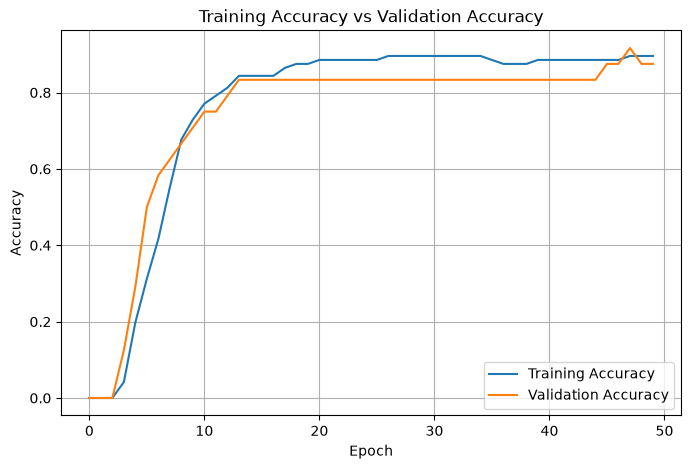

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training Accuracy vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig(
    "Screenshots/Task3_Accuracy_Graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

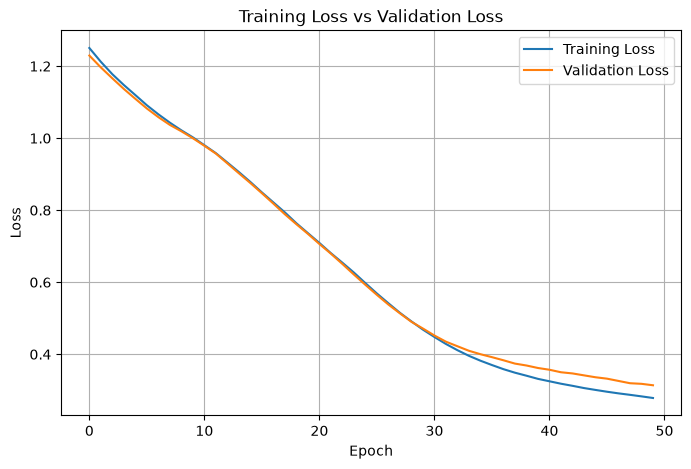

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training Loss vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "Screenshots/Task3_Loss_Graph.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

   ### Task 3 Explanation

The neural network was trained for 50 epochs using the Iris dataset. During training, the model's accuracy increased from 21.88% in the first epoch to 87.50% by the final epoch. The validation accuracy also improved from 29.17% to 83.33%, showing that the model learned useful patterns from the training data and was able to generalize to unseen validation data.

The loss values showed a consistent improvement during training. Training loss decreased from 1.1598 in the first epoch to 0.3188 in the final epoch, while validation loss decreased from 1.1016 to 0.3614. A decreasing loss indicates that the model's predictions became more accurate as training progressed.

The training and validation curves demonstrate that the model improved significantly over the 50 epochs. The final training and validation accuracies are relatively close, with only a small difference of approximately 4.17 percentage points. Similarly, the training and validation losses remain close. Therefore, there is no strong evidence of severe overfitting. Overall, the graphs indicate that the neural network successfully learned to classify the Iris dataset.

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 80.00%
Test Loss: 0.3600


In [15]:
y_prob = model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 30


In [16]:
results = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,2
6,0,0
7,0,0
8,2,2
9,1,1


In [17]:
target_names = iris.target_names

for i in range(5):
    print(
        f"Example {i+1}: "
        f"Actual = {target_names[y_test.iloc[i]]}, "
        f"Predicted = {target_names[y_pred[i]]}"
    )

Example 1: Actual = setosa, Predicted = setosa
Example 2: Actual = virginica, Predicted = virginica
Example 3: Actual = versicolor, Predicted = versicolor
Example 4: Actual = versicolor, Predicted = versicolor
Example 5: Actual = setosa, Predicted = setosa


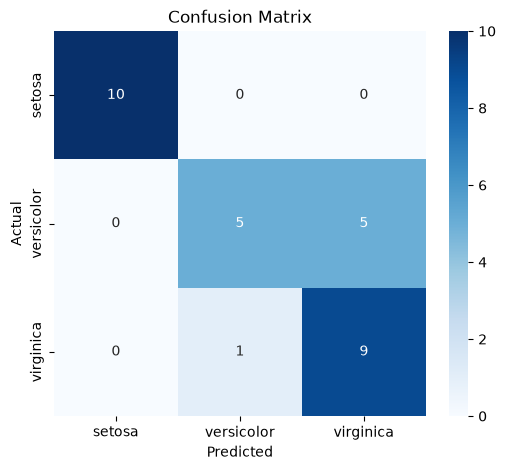

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    "Screenshots/Task4_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      0.50      0.62        10
   virginica       0.64      0.90      0.75        10

    accuracy                           0.80        30
   macro avg       0.83      0.80      0.79        30
weighted avg       0.83      0.80      0.79        30



## Task 4 — Model Evaluation and Prediction

### Model Performance

The trained Artificial Neural Network was evaluated on the 30 unseen test samples from the Iris dataset. The model achieved an overall test accuracy of **80%**, showing that it was able to correctly classify most of the unseen flower samples.

The classification report shows that the model performed best on the **setosa** class. Setosa achieved a precision, recall, and F1-score of **1.00**, meaning all setosa samples were correctly identified. The model also achieved a relatively high recall of **0.90** for the virginica class, although its precision was **0.64**.

The **versicolor** class was more difficult for the neural network to distinguish. It achieved a precision of **0.83**, but its recall was only **0.50**. This indicates that several actual versicolor samples were incorrectly classified as another class, most likely virginica.

Overall, the model achieved a macro-average precision of **0.83**, recall of **0.80**, and F1-score of **0.79**. The results show that the neural network learned useful patterns from the Iris dataset, but some overlap between versicolor and virginica characteristics caused incorrect predictions. Increasing the amount of training data, tuning the network architecture, or adjusting the training parameters could potentially improve the model's performance.